# 03 - Baseline: Multinomial Naive Bayes

Este notebook entrena y evalúa el modelo baseline usando **Multinomial Naive Bayes** sobre la codificación BoW generada en `02_encoding.ipynb`.

## Flujo
1. Cargar los artefactos de `02_encoding.ipynb` (matrices sparse + labels).
2. Ajustar el hiperparámetro `alpha` usando **validación cruzada (5-fold CV)** sobre `X_tr`.
3. Evaluar el mejor alpha en `X_val` (validación hold-out) para confirmar.
4. Re-entrenar el modelo final con `X_train_bow` completo.
5. Evaluar **una sola vez** sobre `X_test_bow` y reportar métricas.
6. Guardar el modelo final.

## Política de evaluación
| Conjunto | Uso en este notebook |
|---|---|
| `X_tr` | Cross-validation 5-fold para elegir `alpha` |
| `X_val` | Validación hold-out para confirmar el mejor alpha |
| `X_train_bow` | Entrenamiento final con todos los datos de train |
| `X_test_bow` | Evaluación final única — no se usa antes de este paso |


## 1. Instalación e imports

In [1]:
!pip install -q scikit-learn scipy joblib matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.sparse import load_npz
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
)

sns.set_theme(style='whitegrid', palette='muted')
SEED     = 42
CV_FOLDS = 5
print('OK — Imports listos. SEED:', SEED)


OK — Imports listos. SEED: 42


## 2. Carga de artefactos

In [3]:
X_tr        = load_npz('X_tr.npz')
X_val       = load_npz('X_val.npz')
X_train_bow = load_npz('X_train_bow.npz')
X_test_bow  = load_npz('X_test_bow.npz')

y_tr    = joblib.load('y_tr.pkl')
y_val   = joblib.load('y_val.pkl')
y_train = joblib.load('y_train.pkl')
y_test  = joblib.load('y_test.pkl')

print('X_tr:        ', X_tr.shape)
print('X_val:       ', X_val.shape)
print('X_train_bow: ', X_train_bow.shape)
print('X_test_bow:  ', X_test_bow.shape)


X_tr:         (1088000, 48184)
X_val:        (272000, 48184)
X_train_bow:  (1360000, 48184)
X_test_bow:   (240000, 48184)


## 3. Ajuste de `alpha` con Cross-Validation (5-fold)

Usamos **`cross_validate`** con `StratifiedKFold(5)` sobre `X_tr` para evaluar cada `alpha`.
Así promediamos el rendimiento en 5 splits distintos, lo que es más robusto que evaluar en un solo hold-out.

`X_val` y `X_test_bow` **no se tocan en este paso**.


In [4]:
alphas  = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
cv      = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
scoring = {'f1': 'f1_macro', 'accuracy': 'accuracy'}

cv_results = []
for alpha in alphas:
    mnb    = MultinomialNB(alpha=alpha)
    scores = cross_validate(mnb, X_tr, y_tr, cv=cv,
                            scoring=scoring, return_train_score=True)
    cv_results.append({
        'alpha':        alpha,
        'cv_f1_mean':   scores['test_f1'].mean(),
        'cv_f1_std':    scores['test_f1'].std(),
        'cv_acc_mean':  scores['test_accuracy'].mean(),
        'cv_train_f1':  scores['train_f1'].mean(),
        'cv_train_acc': scores['train_accuracy'].mean(),
    })
    print(f"alpha={alpha:<5} | CV val F1: {scores['test_f1'].mean():.4f}"
          f" ± {scores['test_f1'].std():.4f}"
          f" | CV train F1: {scores['train_f1'].mean():.4f}")

df_cv      = pd.DataFrame(cv_results)
best_alpha = df_cv.loc[df_cv['cv_f1_mean'].idxmax(), 'alpha']
print(f'\nMejor alpha (CV): {best_alpha}')


alpha=0.01  | CV val F1: 0.7760 ± 0.0009 | CV train F1: 0.7949
alpha=0.05  | CV val F1: 0.7766 ± 0.0009 | CV train F1: 0.7948
alpha=0.1   | CV val F1: 0.7772 ± 0.0008 | CV train F1: 0.7946
alpha=0.5   | CV val F1: 0.7788 ± 0.0007 | CV train F1: 0.7939
alpha=1.0   | CV val F1: 0.7795 ± 0.0007 | CV train F1: 0.7932
alpha=2.0   | CV val F1: 0.7803 ± 0.0007 | CV train F1: 0.7921
alpha=5.0   | CV val F1: 0.7805 ± 0.0006 | CV train F1: 0.7899

Mejor alpha (CV): 5.0


### 3.1 Gráfica: F1 CV Train vs Validación por alpha

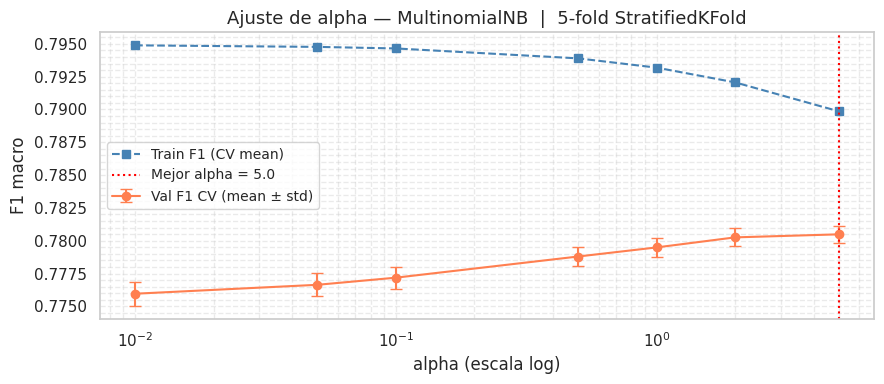

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(df_cv['alpha'], df_cv['cv_train_f1'],
        marker='s', linestyle='--', color='steelblue', label='Train F1 (CV mean)')
ax.errorbar(df_cv['alpha'], df_cv['cv_f1_mean'],
            yerr=df_cv['cv_f1_std'],
            marker='o', linestyle='-', color='coral',
            capsize=4, label='Val F1 CV (mean ± std)')
ax.axvline(x=best_alpha, color='red', linestyle=':', linewidth=1.5,
           label=f'Mejor alpha = {best_alpha}')

ax.set_xscale('log')
ax.set_xlabel('alpha (escala log)', fontsize=12)
ax.set_ylabel('F1 macro', fontsize=12)
ax.set_title(f'Ajuste de alpha — MultinomialNB  |  5-fold StratifiedKFold', fontsize=13)
ax.legend(fontsize=10)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## 4. Confirmación en Validación Hold-out (`X_val`)

Entrenamos con `best_alpha` sobre `X_tr` completo y evaluamos en `X_val`.
Guardamos métricas de **train** y **val** para compararlas con el test.


In [6]:
model_val = MultinomialNB(alpha=best_alpha)
model_val.fit(X_tr, y_tr)

def get_metrics(y_true, y_pred, y_proba):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'f1_macro':  f1_score(y_true, y_pred, average='macro'),
        'precision': precision_score(y_true, y_pred, average='macro'),
        'recall':    recall_score(y_true, y_pred, average='macro'),
        'roc_auc':   roc_auc_score(y_true, y_proba),
    }

y_pred_tr   = model_val.predict(X_tr)
y_proba_tr  = model_val.predict_proba(X_tr)[:, 1]
metrics_train = get_metrics(y_tr, y_pred_tr, y_proba_tr)

y_pred_val  = model_val.predict(X_val)
y_proba_val = model_val.predict_proba(X_val)[:, 1]
metrics_val = get_metrics(y_val, y_pred_val, y_proba_val)

print('=== Métricas Train (X_tr) ===')
for k, v in metrics_train.items():
    print(f'  {k:<12}: {v:.4f}')
print('\n=== Métricas Validación Hold-out (X_val) ===')
for k, v in metrics_val.items():
    print(f'  {k:<12}: {v:.4f}')
print('\n', classification_report(y_val, y_pred_val,
      target_names=['Negativo', 'Positivo']))


=== Métricas Train (X_tr) ===
  accuracy    : 0.7890
  f1_macro    : 0.7890
  precision   : 0.7892
  recall      : 0.7890
  roc_auc     : 0.8620

=== Métricas Validación Hold-out (X_val) ===
  accuracy    : 0.7810
  f1_macro    : 0.7809
  precision   : 0.7812
  recall      : 0.7810
  roc_auc     : 0.8534

               precision    recall  f1-score   support

    Negativo       0.77      0.79      0.78    135974
    Positivo       0.79      0.77      0.78    136026

    accuracy                           0.78    272000
   macro avg       0.78      0.78      0.78    272000
weighted avg       0.78      0.78      0.78    272000



### 4.1 Gráfica: Métricas Train vs Validación

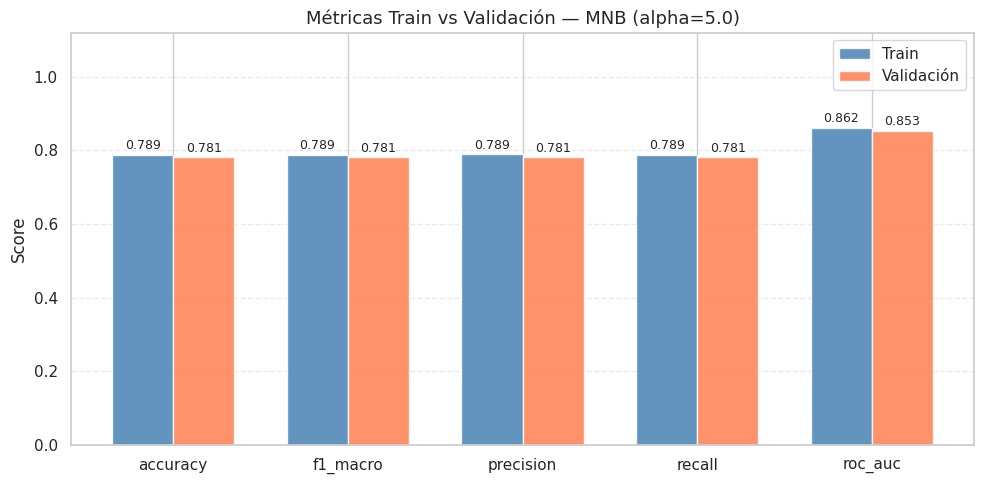

In [7]:
metric_names = ['accuracy', 'f1_macro', 'precision', 'recall', 'roc_auc']
x = np.arange(len(metric_names))
w = 0.35

vals_tr  = [metrics_train[m] for m in metric_names]
vals_val = [metrics_val[m]   for m in metric_names]

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, vals_tr,  w, label='Train',      color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + w/2, vals_val, w, label='Validación', color='coral',      alpha=0.85)

ax.bar_label(bars1, fmt='%.3f', fontsize=9, padding=2)
ax.bar_label(bars2, fmt='%.3f', fontsize=9, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Métricas Train vs Validación — MNB (alpha={best_alpha})', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


### 4.2 Matriz de Confusión — Validación Hold-out

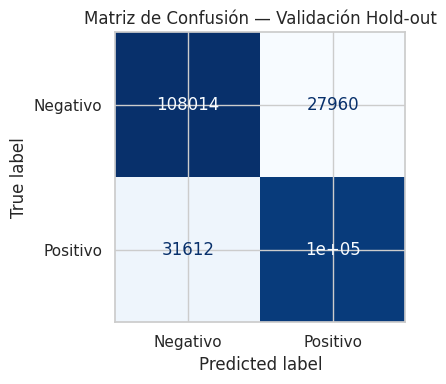

In [8]:
cm_val = confusion_matrix(y_val, y_pred_val)
disp   = ConfusionMatrixDisplay(cm_val, display_labels=['Negativo', 'Positivo'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Validación Hold-out', fontsize=12)
plt.tight_layout()
plt.show()


## 5. Entrenamiento Final

Re-entrenamos con `best_alpha` usando **todo** `X_train_bow` (1,360,000 filas).


In [9]:
model_final = MultinomialNB(alpha=best_alpha)
model_final.fit(X_train_bow, y_train)
print(f'Modelo final entrenado: alpha={best_alpha} | docs={X_train_bow.shape[0]:,}')


Modelo final entrenado: alpha=5.0 | docs=1,360,000


## 6. Evaluación Final en Test

Este es el **único momento** en que usamos `X_test_bow`.


In [10]:
y_pred_test  = model_final.predict(X_test_bow)
y_proba_test = model_final.predict_proba(X_test_bow)[:, 1]
metrics_test = get_metrics(y_test, y_pred_test, y_proba_test)

print('=== EVALUACIÓN FINAL — MultinomialNB ===')
for k, v in metrics_test.items():
    print(f'  {k:<12}: {v:.4f}')
print()
print(classification_report(y_test, y_pred_test,
      target_names=['Negativo', 'Positivo']))


=== EVALUACIÓN FINAL — MultinomialNB ===
  accuracy    : 0.7827
  f1_macro    : 0.7826
  precision   : 0.7828
  recall      : 0.7826
  roc_auc     : 0.8552

              precision    recall  f1-score   support

    Negativo       0.78      0.79      0.79    120129
    Positivo       0.79      0.77      0.78    119871

    accuracy                           0.78    240000
   macro avg       0.78      0.78      0.78    240000
weighted avg       0.78      0.78      0.78    240000



### 6.1 Matriz de Confusión — Test Final

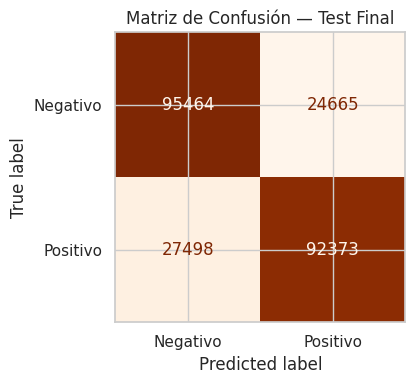

In [11]:
cm_test = confusion_matrix(y_test, y_pred_test)
disp2   = ConfusionMatrixDisplay(cm_test, display_labels=['Negativo', 'Positivo'])

fig, ax = plt.subplots(figsize=(5, 4))
disp2.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Matriz de Confusión — Test Final', fontsize=12)
plt.tight_layout()
plt.show()


## 7. Comparativa Global: Train / Val / Test

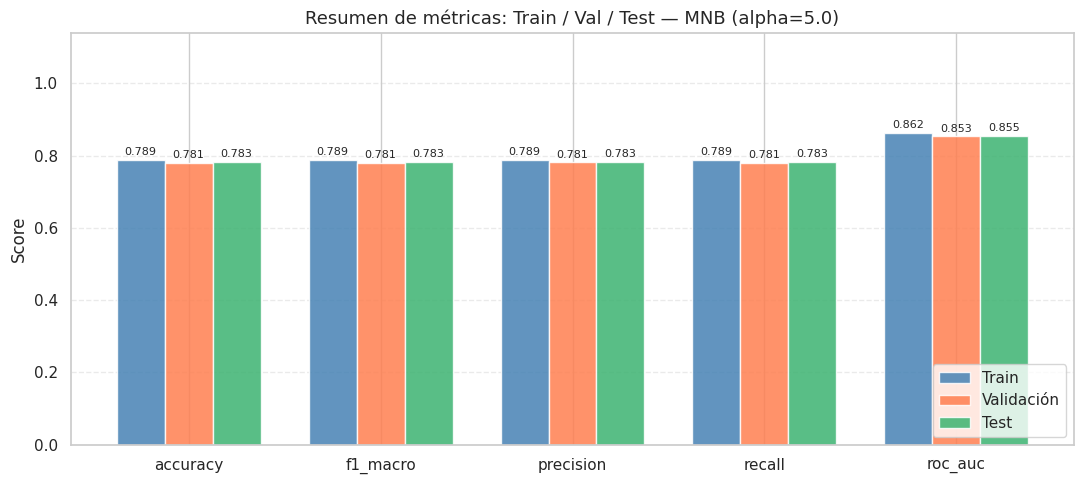

In [12]:
metric_names = ['accuracy', 'f1_macro', 'precision', 'recall', 'roc_auc']
x = np.arange(len(metric_names))
w = 0.25

vals_tr_f   = [metrics_train[m] for m in metric_names]
vals_val_f  = [metrics_val[m]   for m in metric_names]
vals_test_f = [metrics_test[m]  for m in metric_names]

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w, vals_tr_f,   w, label='Train',      color='steelblue', alpha=0.85)
b2 = ax.bar(x,     vals_val_f,  w, label='Validación', color='coral',     alpha=0.85)
b3 = ax.bar(x + w, vals_test_f, w, label='Test',       color='mediumseagreen', alpha=0.85)

for bars in (b1, b2, b3):
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2, rotation=0)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.14)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Resumen de métricas: Train / Val / Test — MNB (alpha={best_alpha})', fontsize=13)
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## 8. Guardar modelo y resultados

In [13]:
joblib.dump(model_final, 'mnb_model.pkl')

results_final = pd.DataFrame([{
    'modelo':    'MultinomialNB',
    'alpha':     best_alpha,
    'train_acc': round(metrics_train['accuracy'],  4),
    'train_f1':  round(metrics_train['f1_macro'],  4),
    'train_auc': round(metrics_train['roc_auc'],   4),
    'val_acc':   round(metrics_val['accuracy'],    4),
    'val_f1':    round(metrics_val['f1_macro'],    4),
    'val_auc':   round(metrics_val['roc_auc'],     4),
    'test_acc':  round(metrics_test['accuracy'],   4),
    'test_f1':   round(metrics_test['f1_macro'],   4),
    'test_auc':  round(metrics_test['roc_auc'],    4),
}])

results_final.to_csv('results_baseline.csv', index=False)
print('Guardados: mnb_model.pkl | results_baseline.csv')
print()
print(results_final.T.to_string(header=False))


Guardados: mnb_model.pkl | results_baseline.csv

modelo     MultinomialNB
alpha                5.0
train_acc          0.789
train_f1           0.789
train_auc          0.862
val_acc            0.781
val_f1            0.7809
val_auc           0.8534
test_acc          0.7827
test_f1           0.7826
test_auc          0.8552


## 9. Predicción en Vivo

Escribe cualquier texto en inglés en la variable `texto` de la celda de abajo y ejecuta.
El pipeline aplica exactamente la misma limpieza que el preprocesamiento (`clean_raw_text`),
vectoriza con el `bow_vectorizer` guardado en `02_encoding.ipynb` y predice con el modelo final.


In [43]:
import re, joblib

# ── 1. Cargar vectorizador (por si se ejecuta esta celda sola) ──────────────
try:
    vectorizer
except NameError:
    vectorizer = joblib.load('bow_vectorizer.pkl')

try:
    model_final
except NameError:
    model_final = joblib.load('mnb_model.pkl')

# ── 2. Misma función de limpieza que en 01_preprocessing.ipynb ─────────────
def clean_raw_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)   # URLs
    text = re.sub(r'@\w+', '', text)              # Menciones
    text = re.sub(r'#\w+', '', text)              # Hashtags
    text = re.sub(r'[^\x00-\x7F]+', '', text)    # Emojis / no-ASCII
    text = re.sub(r'\s+', ' ', text).strip()      # Espacios extra
    return text

# ════════════════════════════════════════════════════════════════════════════
# ↓↓↓  CAMBIA ESTE TEXTO  ↓↓↓
texto = "im gonna kill myself"
# ════════════════════════════════════════════════════════════════════════════

# ── 3. Pipeline: limpiar → vectorizar → predecir ───────────────────────────
texto_limpio = clean_raw_text(texto)
X_input      = vectorizer.transform([texto_limpio])
pred         = model_final.predict(X_input)[0]
proba        = model_final.predict_proba(X_input)[0]

label      = '😊 Positivo' if pred == 1 else '😞 Negativo'
confianza  = proba[pred]
barra      = '█' * int(confianza * 30) + '░' * (30 - int(confianza * 30))

print('─' * 50)
print(f'  Texto original : {texto}')
print(f'  Texto limpio   : {texto_limpio}')
print('─' * 50)
print(f'  Predicción     : {label}')
print(f'  Confianza      : {confianza:.1%}  {barra}')
print(f'  P(Negativo)    : {proba[0]:.4f}')
print(f'  P(Positivo)    : {proba[1]:.4f}')
print('─' * 50)


──────────────────────────────────────────────────
  Texto original : im gonna kill myself
  Texto limpio   : im gonna kill myself
──────────────────────────────────────────────────
  Predicción     : 😞 Negativo
  Confianza      : 78.0%  ███████████████████████░░░░░░░
  P(Negativo)    : 0.7804
  P(Positivo)    : 0.2196
──────────────────────────────────────────────────
